In [1]:
### Event display

In [5]:
from analysis.event_display.event_display import plot_event_2d, plot_event_3d
from watchmal.dataset.h5_dataset import H5CommonDataset
import numpy as np
import h5py
import matplotlib
import matplotlib.pyplot as plt

In [6]:
geometry_file = '/vols/hyperk/WCTE/ML_2025/cds_geometry/geometries/WCTE_geometry_v1.12.21.npz'
geo_file = np.load(geometry_file, 'r')
keys = geo_file.files
print(keys)
 

['tube_no', 'position', 'orientation']


[    0   992   992  1202  1326  1439  1616  2280  2301  2773  3027  4118
  4893  5522  5541  5577  6118  6702  7213  8199  8242  8959  9680 10347
 10572 10958 11878 12571 13488 13642 14479 15023 15028 15360 15508 15544
 15630 16016 16784 17479 17947 18137 18512 19226 19460 20110 21142 21419
 21949 21985 22042 22611 22799 23646 24016 24322 24631 25111 25972 26802
 27020 27831 28752 29127 30023 30599 30903 31054 31810 32397 32444 33163
 34284 34291 34655 34699 35088 35207 35228 36075 36452 36930 37112 38128
 38293 39227 39394 39491 40035 40789 40956 41991 42000 42784 42840 43630
 44020 45096 45119 45393]
<KeysViewHDF5 ['angles', 'energies', 'event_hits_index', 'event_ids', 'fully_contained', 'hit_charge', 'hit_pmt', 'hit_time', 'labels', 'positions', 'root_files', 'veto', 'veto2']>
max 868.6000366210938, 0.0
[824.2     824.7     825.30005 839.30005 824.10004 824.7     824.60004
 823.80005 830.5     819.5     823.9     823.10004 824.5     824.4
 825.80005 822.7     821.      823.5     821

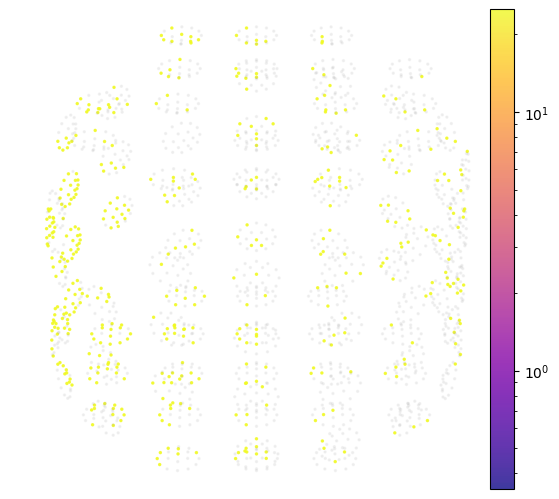

In [45]:
# h5_path = '/vols/hyperk/WCTE/ML_2025/cds_geometry/h5_files/wcte_CDS_pgun_e-_10M_mu-_10M_0to1GeV_fixedFC_fixed_mu.h5'
h5_path = '/vols/hyperk/users/nprouse/WCTE/ML/WCTE_April2026/WCTE_1.5.2_April2026_0-1GeV_3M_e-_3M_mu-_firstT.h5'

# h5 = H5CommonDataset(h5_path)
# hit_charge = h5.load_hits('hit_charge')

# def load_hits(h5_file, h5_key):
#     return np.array(h5_file[h5_key])

h5_file = h5py.File(h5_path, "r")

event_hits_index = np.append(h5_file["event_hits_index"], h5_file["hit_pmt"].shape[0]).astype(np.int64)
# hit_pmt = load_hits(h5_file, "hit_pmt")
# hit_time = load_hits(h5_file, "hit_time")
# hit_charge = load_hits(h5_file, 'hit_charge')

print(event_hits_index[:100])

event_id = 8
start = event_hits_index[event_id]
stop = event_hits_index[event_id + 1]

print(h5_file.keys())

event_hit_pmts = h5_file['hit_pmt'][start:stop]
event_hit_charges = h5_file['hit_charge'][start:stop]
event_hit_times = h5_file['hit_time'][start:stop]

hit_positions = geo_file['position'][event_hit_pmts,:]

n_pmts = geo_file['position'].shape[0]
pmt_list = np.arange(0, n_pmts, 1)

# unhit_mask = []
# for i in pmt_list:
#     if i in event_hits_index:
#         unhit_mask.append(False)
#     else:
#         unhit_mask.append(True)

unhit_mask = ~np.isin(pmt_list, event_hit_pmts)
unhit_pmts = geo_file['position'][unhit_mask]

print(f'max {event_hit_times.max()}, {event_hit_times.min()}')

# print(event_hit_pmts)
# print(unhit_pmts)

# x_range = np.linspace(min(hit_positions[:,0]), max(hit_positions[:,0]), 278)
# y_range = np.linspace(min(hit_positions[:,1]), max(hit_positions[:,1]), 278)
# z_range = np.linspace(min(hit_positions[:,2]), max(hit_positions[:,2]), 278)

# data_coords = np.column_stack([x_range, y_range, z_range])

# unhit_pmt_coords = 

plot_event_3d(event_hit_times, hit_positions, unhit_pmts)

print(event_hit_times isnan)

count = 0
for i in range(1, len(event_hits_index)):
    if event_hits_index[i] == event_hits_index[i-1]:
        count += 1

        

print(count)

[    0   992   992  1202  1326  1439  1616  2280  2301  2773  3027  4118
  4893  5522  5541  5577  6118  6702  7213  8199  8242  8959  9680 10347
 10572 10958 11878 12571 13488 13642 14479 15023 15028 15360 15508 15544
 15630 16016 16784 17479 17947 18137 18512 19226 19460 20110 21142 21419
 21949 21985 22042 22611 22799 23646 24016 24322 24631 25111 25972 26802
 27020 27831 28752 29127 30023 30599 30903 31054 31810 32397 32444 33163
 34284 34291 34655 34699 35088 35207 35228 36075 36452 36930 37112 38128
 38293 39227 39394 39491 40035 40789 40956 41991 42000 42784 42840 43630
 44020 45096 45119 45393]
<KeysViewHDF5 ['angles', 'energies', 'event_hits_index', 'event_ids', 'fully_contained', 'hit_charge', 'hit_pmt', 'hit_time', 'labels', 'positions', 'root_files', 'veto', 'veto2']>
[ 5.8000011e+00  6.3000011e+00  6.8999996e+00  2.0900002e+01
  5.7000008e+00  6.3000011e+00  6.2000008e+00  5.3999996e+00
  1.2100000e+01  1.1000004e+00  5.5000000e+00  4.7000008e+00
  6.1000004e+00  6.0000000

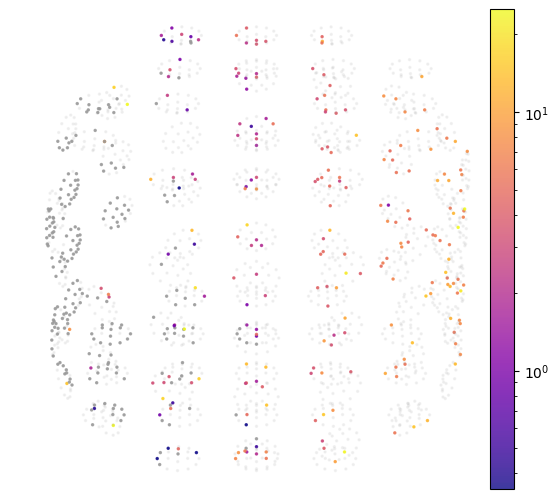

In [50]:
# h5_path = '/vols/hyperk/WCTE/ML_2025/cds_geometry/h5_files/wcte_CDS_pgun_e-_10M_mu-_10M_0to1GeV_fixedFC_fixed_mu.h5'
h5_path = '/vols/hyperk/users/nprouse/WCTE/ML/WCTE_April2026/WCTE_1.5.2_April2026_0-1GeV_3M_e-_3M_mu-_medianT.h5'

# h5 = H5CommonDataset(h5_path)
# hit_charge = h5.load_hits('hit_charge')

# def load_hits(h5_file, h5_key):
#     return np.array(h5_file[h5_key])

h5_file = h5py.File(h5_path, "r")

event_hits_index = np.append(h5_file["event_hits_index"], h5_file["hit_pmt"].shape[0]).astype(np.int64)
# hit_pmt = load_hits(h5_file, "hit_pmt")
# hit_time = load_hits(h5_file, "hit_time")
# hit_charge = load_hits(h5_file, 'hit_charge')

print(event_hits_index[:100])

event_id = 8
start = event_hits_index[event_id]
stop = event_hits_index[event_id + 1]

print(h5_file.keys())

event_hit_pmts = h5_file['hit_pmt'][start:stop]
event_hit_charges = h5_file['hit_charge'][start:stop]
event_hit_times = h5_file['hit_time'][start:stop]

hit_positions = geo_file['position'][event_hit_pmts,:]

n_pmts = geo_file['position'].shape[0]
pmt_list = np.arange(0, n_pmts, 1)

# unhit_mask = []
# for i in pmt_list:
#     if i in event_hits_index:
#         unhit_mask.append(False)
#     else:
#         unhit_mask.append(True)

unhit_mask = ~np.isin(pmt_list, event_hit_pmts)
unhit_pmts = geo_file['position'][unhit_mask]

# print(event_hit_pmts)
# print(unhit_pmts)

# x_range = np.linspace(min(hit_positions[:,0]), max(hit_positions[:,0]), 278)
# y_range = np.linspace(min(hit_positions[:,1]), max(hit_positions[:,1]), 278)
# z_range = np.linspace(min(hit_positions[:,2]), max(hit_positions[:,2]), 278)

# data_coords = np.column_stack([x_range, y_range, z_range])

# unhit_pmt_coords = 

plot_event_3d(event_hit_times, hit_positions, unhit_pmts)

print(event_hit_times)
print(f'max {np.nanmax(event_hit_times)}, {np.nanmin(event_hit_times)}')

count = 0
for i in range(1, len(event_hits_index)):
    if event_hits_index[i] == event_hits_index[i-1]:
        count += 1
        
print(sum(np.isnan(event_hit_times))/len(event_hit_times))

print(count)